# Fase 1 — Exploración y control de calidad (QC)

Pronóstico de GHI horaria en Tamaulipas (NSRDB). Este notebook aplica la fase de
exploración: estructura de los datos, selección del nodo de arranque, reporte de
calidad, e investigación de la variable `fill_flag`.

Reglas del proyecto (ver `forecasting/README.md`): target `kt = ghi/clearsky_ghi`,
solo horas operativas (`clearsky_ghi>0` y `zenith<85`), validación walk-forward,
nodo descrito por lat/lon/msnm (no one-hot), baseline smart persistence.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))   # raíz del repo en el path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecasting import config as C
from forecasting.data import loaders as L
from forecasting.data import qc

pd.set_option('display.width', 120)
print('Años:', C.ANIOS_TODOS, '| horas operativas: csghi>0 & zen <', C.ZENITH_MAX)

Años: [2020, 2021, 2022, 2023, 2024] | horas operativas: csghi>0 & zen < 85.0


## 1. Estructura de los datos

Esquema del consolidado horario y clasificación anti-leakage de las variables.

In [2]:
import pyarrow.parquet as pq
pf = pq.ParquetFile(C.ruta_parquet(2023))
print('filas/año:', f'{pf.metadata.num_rows:,}', '| columnas:', len(pf.schema_arrow.names))
print('\nDeterministas (usables en t+1):', C.DETERMINISTAS)
print('Estáticas del nodo             :', C.ESTATICAS)
print('Observadas (rezagar):', C.OBSERVADAS)

filas/año: 38,403,840 | columnas: 31

Deterministas (usables en t+1): ['clearsky_ghi', 'clearsky_dni', 'clearsky_dhi', 'solar_zenith_angle']
Estáticas del nodo             : ['latitude', 'longitude', 'msnm']
Observadas (rezagar): ['ghi', 'dni', 'dhi', 'ghi_uv_280_400', 'ghi_uv_295_385', 'cloud_type', 'cloud_fill_flag', 'fill_flag', 'temperature', 'dew_point', 'relative_humidity', 'pressure', 'precipitable_water', 'wind_speed', 'wind_direction', 'surface_albedo', 'aerosol_optical_depth', 'alpha', 'asymmetry', 'ssa', 'ozone']


## 2. Selección del nodo de arranque

Se elige automáticamente por calidad: completo en todos los años, relleno por
debajo de la mediana, y cercano a Cd. Victoria.

In [3]:
info = qc.seleccionar_nodo_arranque()
info

  [2020] nodos=4384 frac_fill medio=0.092
  [2021] nodos=4384 frac_fill medio=0.101
  [2022] nodos=4384 frac_fill medio=0.100
  [2023] nodos=4384 frac_fill medio=0.078
  [2024] nodos=4384 frac_fill medio=0.082

>> Nodo de arranque: 1736 (lat 23.73, lon -99.18, 381 msnm) | fill=0.091 | 2192 candidatos de calidad


{'nodo_id': 1736,
 'latitude': 23.73,
 'longitude': -99.18,
 'msnm': 381.0,
 'frac_fill': 0.09068044015270604,
 'frac_operativa': 0.46948561519075777,
 'candidatos': 2192}

## 3. Reporte de calidad del nodo elegido

In [4]:
rep = qc.reporte_qc(info['nodo_id'])


QC nodo 1736 | años [2020, 2021, 2022, 2023, 2024]
[1] Estructura: 43848 horas (2020-01-01 00:00:00 -> 2024-12-31 23:00:00), UTC
    Timestamps faltantes (reindex): 0 (0.000%)  | duplicados: 0 (drop previo)
[2] Rangos físicos (valores fuera de rango plausible):
    sin valores imposibles
[3] fill_flag (relleno): {0: 39872, 4: 300, 7: 263, 11: 180, 14: 587, 18: 126, 21: 108, 25: 83, 29: 335, 32: 76, 36: 75, 39: 42, 43: 303, 46: 45, 50: 43, 54: 47, 57: 197, 61: 39, 64: 44, 68: 37, 71: 236, 75: 31, 79: 31, 82: 30, 86: 205, 89: 29, 93: 31, 96: 29, 100: 424}
[4] Horas operativas (csghi>0 & zen<85): 20586 (46.9%)
[5] kt operativas: n=20586 nan=0 | min=0.020 p50=0.993 max=1.000
    kt>1 antes de recorte: 0
[6] Correlación (operativas) de cada variable con kt [top +/- 5]:
    positivas: {'temperature': 0.34, 'ghi_uv_295_385': 0.51, 'ghi_uv_280_400': 0.52, 'ghi': 0.56, 'dni': 0.83}
    negativas: {'cloud_type': -0.67, 'relative_humidity': -0.34, 'ssa': -0.31, 'precipitable_water': -0.27, 'clou

## 4. Distribución del target kt

kt está muy sesgado a 1 (región despejada). El reto del modelo es la cola nubosa.

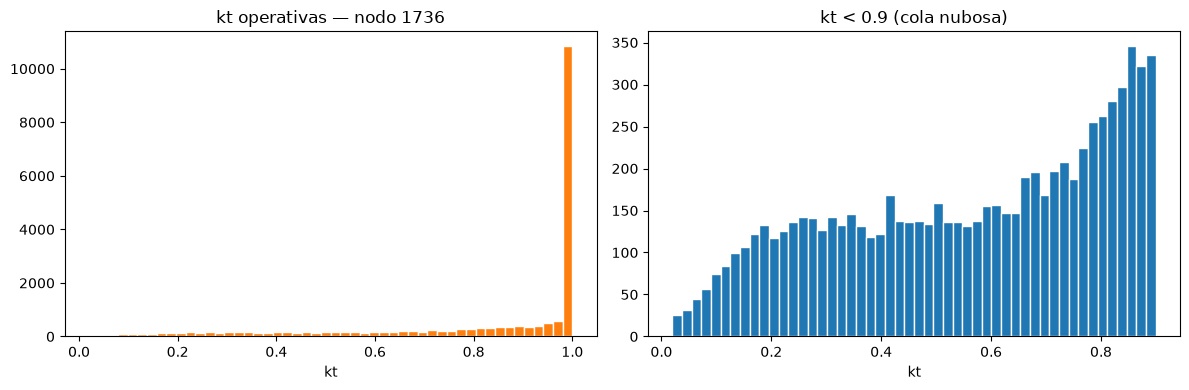

mediana kt: 0.993 | % horas con kt<0.7: 23.7


In [5]:
df = L.cargar_nodo(info['nodo_id'])
op = (df[C.COL_CLEARSKY] > C.CLEARSKY_MIN) & (df[C.COL_ZENITH] < C.ZENITH_MAX)
kt = (df.loc[op, C.COL_GHI] / df.loc[op, C.COL_CLEARSKY]).clip(upper=C.KT_MAX)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(kt, bins=50, color='tab:orange', edgecolor='white')
ax[0].set_title(f'kt operativas — nodo {info["nodo_id"]}'); ax[0].set_xlabel('kt')
ax[1].hist(kt[kt < 0.9], bins=50, color='tab:blue', edgecolor='white')
ax[1].set_title('kt < 0.9 (cola nubosa)'); ax[1].set_xlabel('kt')
plt.tight_layout(); plt.show()
print('mediana kt:', round(kt.median(), 3), '| % horas con kt<0.7:', round(100*(kt<0.7).mean(), 1))

## 5. Investigación de `fill_flag`

La documentación dice 0–5, pero la columna real va 0–100. Cruzamos cada valor con
kt y nubosidad medias para inferir su significado.

In [6]:
tf = qc.tabla_fill_flag(nodo_id=info['nodo_id'])
tf.head(12)

,fill_flag,n_obs,pct,n_operativas,ghi_medio,clearsky_ghi_medio,kt_medio_op,cloud_type_medio,cloud_fill_flag_medio,zenith_medio
0,0,39872,90.932,18169,241.55,283.29,0.8476,2.05,0.00,90.79
1,4,300,0.684,275,311.60,448.56,0.7075,3.56,0.00,58.90
2,7,263,0.600,224,287.54,395.88,0.7532,3.27,0.00,62.39
3,11,180,0.411,143,243.44,336.91,0.7365,3.25,0.65,66.25
4,14,587,1.339,294,141.72,188.42,0.7001,3.70,0.55,88.61
5,18,126,0.287,112,217.29,336.31,0.6897,4.06,0.65,66.42
6,21,108,0.246,84,204.32,290.31,0.7454,3.07,1.45,69.04
7,25,83,0.189,67,196.78,293.54,0.6973,3.60,1.43,69.18
8,29,335,0.764,141,79.46,127.58,0.5966,4.48,1.42,91.14
9,32,76,0.173,65,206.93,318.61,0.6839,4.45,1.68,66.88


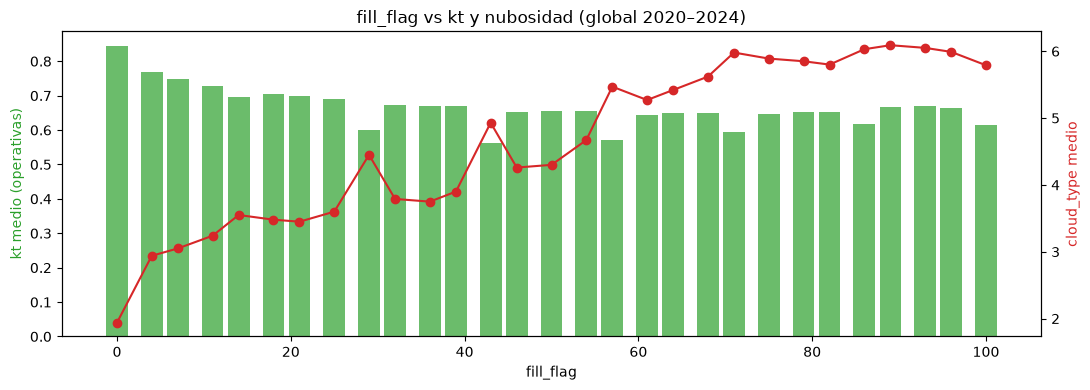

fill_flag=0 concentra el 90.9 % de las observaciones


In [7]:
tg = pd.read_csv(os.path.join(C.DIR_RESULTADOS, 'fill_flag_frecuencia_global_2020_2024.csv'))
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(tg['fill_flag'], tg['kt_medio_op'], width=2.5, color='tab:green', alpha=.7)
ax1.set_xlabel('fill_flag'); ax1.set_ylabel('kt medio (operativas)', color='tab:green')
ax2 = ax1.twinx()
ax2.plot(tg['fill_flag'], tg['cloud_type_medio'], 'o-', color='tab:red')
ax2.set_ylabel('cloud_type medio', color='tab:red')
plt.title('fill_flag vs kt y nubosidad (global 2020–2024)')
plt.tight_layout(); plt.show()
print('fill_flag=0 concentra el', round(tg.loc[tg.fill_flag==0,"pct"].iloc[0],1), '% de las observaciones')

**Lectura:** a mayor `fill_flag` baja kt y sube la nubosidad → `fill_flag` es un
**porcentaje de relleno** del pixel satelital (peor calidad = más nublado), no la
categórica 0–5 documentada. Ese diccionario corresponde a `cloud_fill_flag` (0–7).

## 6. Conclusiones de la Fase 1

- Datos íntegros para el nodo 1736 (0 huecos, 0 imposibles).
- kt sesgado a 1 → smart persistence será un baseline exigente.
- `fill_flag` = % de relleno; pendiente decidir si se usa como umbral de calidad.
- Siguiente: Fase 2 (baseline smart persistence + métricas).